In [1]:
from sqlalchemy import create_engine
import pandas as pd
from dotenv import load_dotenv
import os
from tqdm import tqdm
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
### uncomment the following section to read the table from SSMS using polars and save it as a parquet file.
# load_dotenv() 
# conn = os.getenv("SCUBA_DEV")
# engine = create_engine(conn)
# sql_query = '''
# SELECT *
#   FROM [MarketingMirror].[NoteExtraction].[NoteTokenCosts]
# '''

# def read_sql_query_in_batches(sql_query, engine, batch_size=100000):
#     total_rows = 0
#     for batch in tqdm(pl.read_database(sql_query,engine,batch_size=100000,iter_batches=True), unit=" batch"):
#         total_rows += len(batch)
#         if total_rows % 1000000 == 0:
#             print(f"Read {total_rows} rows")
#         yield batch

# pdf = pl.concat(read_sql_query_in_batches(sql_query, engine, batch_size=100000))
# pdf.write_parquet("C:\\Users\\spande\\SparkleHealth\\SparkleHealth\\usp_FinalOutput\\NoteTokenCosts.parquet")

In [3]:
### upload the saved parquet file
df_notetokencost_all = pd.read_parquet("C:\\Users\\spande\\SparkleHealth\\SparkleHealth\\usp_FinalOutput\\NoteTokenCosts.parquet", engine='pyarrow')
print(df_notetokencost_all.shape)

(1586849, 16)


In [4]:
df_notetokencost_all.columns.to_list()

['ProviderEpicId',
 'ClinicalNoteTextKey',
 'ClinicalNoteEpicId',
 'EncounterEpicCsn',
 'Type',
 'ServiceInstant',
 'PrimarySpecialty',
 'DepartmentName',
 'DepartmentCenter',
 'LocationName',
 'PromptTokens',
 'CompletionTokensEstimate',
 'TotalTokensEstimate',
 'PromptCostUSD',
 'CompletionCostUSD',
 'TotalCostUSD']

In [5]:
# There are around 600k rows missing totalcost value. We can remove them from the analysis.
df_notetokencost_all.isna().sum()

ProviderEpicId                   0
ClinicalNoteTextKey              0
ClinicalNoteEpicId               0
EncounterEpicCsn                 0
Type                             0
ServiceInstant                   0
PrimarySpecialty                 0
DepartmentName                   0
DepartmentCenter                 0
LocationName                     0
PromptTokens                601024
CompletionTokensEstimate    601024
TotalTokensEstimate         601024
PromptCostUSD               601024
CompletionCostUSD           601024
TotalCostUSD                601024
dtype: int64

In [36]:
df_notetokencost = df_notetokencost_all.dropna().copy()
print(df_notetokencost.shape)

(985825, 16)


In [37]:
df_notetokencost['TotalCostUSD'] = pd.to_numeric(df_notetokencost['TotalCostUSD'], errors='coerce')

In [8]:
df_notetokencost.describe()

,ClinicalNoteTextKey,ServiceInstant,PromptTokens,CompletionTokensEstimate,TotalTokensEstimate,TotalCostUSD
count,9.858250e+05,985825,985825.000000,985825.0,985825.000000,985825.000000
mean,1.195252e+08,2025-04-03 01:56:38.993594,2248.561976,26.0,2274.561976,0.005881
min,1.025379e+08,2024-12-04 09:52:00,383.000000,26.0,409.000000,0.001218
25%,1.166203e+08,2025-02-04 10:20:00,1043.000000,26.0,1069.000000,0.002868
50%,1.191378e+08,2025-03-31 14:40:00,1743.000000,26.0,1769.000000,0.004618
75%,1.216373e+08,2025-05-23 13:16:00,2873.000000,26.0,2899.000000,0.007443
max,1.394961e+08,2025-12-03 07:30:00,52337.000000,26.0,52363.000000,0.131103
std,4.274073e+06,NaN,1856.686915,0.0,1856.686915,0.004642


In [9]:
df_notetokencost.nunique()

ProviderEpicId                2791
ClinicalNoteTextKey         985825
ClinicalNoteEpicId          985825
EncounterEpicCsn            935271
Type                             2
ServiceInstant              108031
PrimarySpecialty               140
DepartmentName                1004
DepartmentCenter                32
LocationName                    79
PromptTokens                 13827
CompletionTokensEstimate         1
TotalTokensEstimate          13827
PromptCostUSD                13827
CompletionCostUSD                1
TotalCostUSD                 13827
dtype: int64

In [10]:
df_notetokencost['Year_Month_Service'] = df_notetokencost['ServiceInstant'].dt.strftime('%Y-%m')

C:\Users\spande\AppData\Local\Temp\1\ipykernel_30036\1044848122.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_notetokencost['Year_Month_Service'] = df_notetokencost['ServiceInstant'].dt.strftime('%Y-%m')


<Axes: xlabel='TotalTokensEstimate', ylabel='TotalCostUSD'>

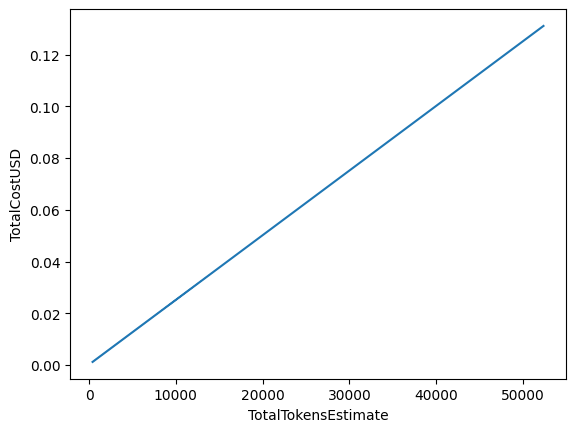

In [11]:
# sanity check - cost varies linearly with number of tokens as expected
sns.lineplot(x=df_notetokencost['TotalTokensEstimate'],y=df_notetokencost['TotalCostUSD'])

total token cost give us information on the size of each note


In [12]:
df_grp_percent = df_notetokencost.groupby('PrimarySpecialty')['TotalCostUSD'].describe(percentiles=[0.10, 0.25, 0.5, 0.75]).reset_index(drop=False)

In [13]:
# fig,ax = plt.subplots(figsize=(20,6))
# sns.boxplot(df_notetokencost.sort_values(by='TotalCostUSD'), x='PrimarySpecialty', y='TotalCostUSD')
# ax.tick_params(axis='x', labelrotation=90)

In [14]:
# distribution of total cost (which directly relates to note size)
# sns.histplot(data=df_notetokencost, x='TotalCostUSD', hue='PrimarySpecialty', legend=False, kde=True, common_norm=True)

In [41]:
# Notes processed per specialty
df_grp_specialty = df_notetokencost.groupby(['PrimarySpecialty'])['ClinicalNoteEpicId'].nunique().sort_values(ascending=False).reset_index(drop=False)
df_grp_specialty_all = df_notetokencost_all.groupby(['PrimarySpecialty'])['ClinicalNoteEpicId'].nunique().sort_values(ascending=False).reset_index(drop=False)
df_grp_specialty_all.rename(columns={'ClinicalNoteEpicId':'TotalNoteCount'}, inplace=True)

In [42]:
df_grp_specialty_all

,PrimarySpecialty,TotalNoteCount
0,Family Medicine,168450
1,Nurse Practitioner,82077
2,Pediatrics,76754
3,Internal Medicine,68425
4,Dermatology,55287
...,...,...
135,Surgical Critical Care,88
136,Oral and Maxillofacial Surgery,69
137,Pediatric Emergency Medicine,23
138,Oral Medicine,23


In [43]:
# provider count per specialty
df_grp_specialty = pd.merge(df_grp_specialty, df_grp_specialty_all, on='PrimarySpecialty')
df_grp_specialty = pd.merge(df_grp_specialty, df_notetokencost.groupby(['PrimarySpecialty'])['ProviderEpicId'].nunique().reset_index(drop=False), on='PrimarySpecialty')
df_grp_specialty.rename(columns={'ClinicalNoteEpicId':'TotalTokenizedNoteCount','ProviderEpicId':'ProviderCount'}, inplace=True)
df_grp_specialty['TokenizedNotesRatio'] = df_grp_specialty['TotalTokenizedNoteCount']/df_grp_specialty['TotalNoteCount']

In [44]:
df_grp_specialty.sort_values(by='TotalTokenizedNoteCount',ascending=False)

,PrimarySpecialty,TotalTokenizedNoteCount,TotalNoteCount,ProviderCount,TokenizedNotesRatio
0,Family Medicine,103549,168450,152,0.614717
1,Nurse Practitioner,49942,82077,112,0.608477
2,Pediatrics,49276,76754,169,0.641999
3,Internal Medicine,42615,68425,104,0.622799
4,Dermatology,34057,55287,53,0.616004
...,...,...,...,...,...
135,Oral and Maxillofacial Surgery,64,69,3,0.927536
136,Pediatric Immunology,62,134,3,0.462687
137,Pediatric Emergency Medicine,21,23,2,0.913043
138,Oral Medicine,18,23,3,0.782609


In [ ]:
df_grp_combined = pd.merge(df_grp_specialty, df_grp_percent, on='PrimarySpecialty').sort_values(by=['TotalNoteCount','ProviderCount'], ascending=False)
df_grp_combined.drop(columns=['count','min','max'],inplace=True)
df_grp_combined.rename(columns={'50%':'median_cost_usd','mean':'mean_cost_usd','std':'std_cost_usd','25%':'25%_cost_usd','75%':'75%_cost_usd'},inplace=True)
df_grp_combined['avg_cost_per_1000notes_usd'] = round(df_grp_combined['median_cost_usd']*1000, 2)

In [77]:
df_grp_combined = df_grp_combined[['PrimarySpecialty',
 'TotalTokenizedNoteCount',
 'TotalNoteCount',
 'TokenizedNotesRatio',
 'ProviderCount',
 'mean_cost_usd',
 'std_cost_usd',
 '25%_cost_usd',
 'median_cost_usd',
 '75%_cost_usd',
 'avg_cost_per_1000notes_usd']]

In [78]:
df_grp_combined['TokenizedNotesRatio'].describe()

count    140.000000
mean       0.636203
std        0.095750
min        0.333333
25%        0.606247
50%        0.619533
75%        0.646226
max        1.000000
Name: TokenizedNotesRatio, dtype: float64

In [79]:
df_grp_combined

,PrimarySpecialty,TotalTokenizedNoteCount,TotalNoteCount,TokenizedNotesRatio,ProviderCount,mean_cost_usd,std_cost_usd,25%_cost_usd,median_cost_usd,75%_cost_usd,avg_cost_per_1000notes_usd
0,Family Medicine,103549,168450,0.614717,152,0.005398,0.003982,0.003005,0.004327,0.006430,5.40
1,Nurse Practitioner,49942,82077,0.608477,112,0.006988,0.005947,0.002970,0.005230,0.009240,6.99
2,Pediatrics,49276,76754,0.641999,169,0.005543,0.003723,0.003240,0.004672,0.006848,5.54
3,Internal Medicine,42615,68425,0.622799,104,0.005328,0.003520,0.003203,0.004435,0.006330,5.33
4,Dermatology,34057,55287,0.616004,53,0.003242,0.001500,0.002417,0.003000,0.003700,3.24
...,...,...,...,...,...,...,...,...,...,...,...
134,Surgical Critical Care,68,88,0.772727,2,0.005578,0.004409,0.002845,0.003507,0.006777,5.58
135,Oral and Maxillofacial Surgery,64,69,0.927536,3,0.002130,0.000569,0.001934,0.002090,0.002265,2.13
138,Oral Medicine,18,23,0.782609,3,0.001672,0.001334,0.001312,0.001365,0.001408,1.67
137,Pediatric Emergency Medicine,21,23,0.913043,2,0.003441,0.001300,0.002605,0.003030,0.003870,3.44


Text(0.5, 1.0, 'avg cost per 1000 notes for all specialities')

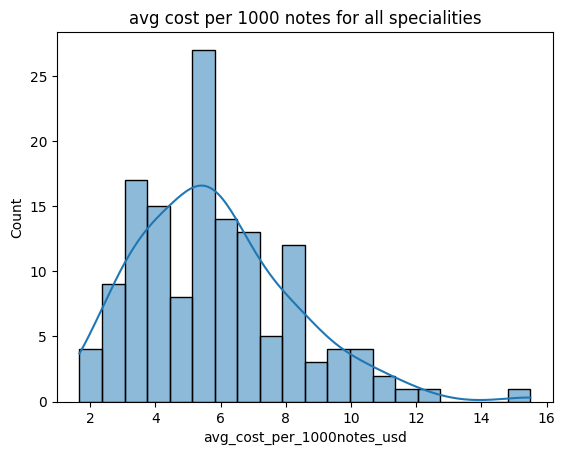

In [80]:
sns.histplot(data=df_grp_combined['avg_cost_per_1000notes_usd'], kde=True, bins= 20)
plt.title('avg cost per 1000 notes for all specialities')

Text(0.5, 1.0, 'Provider Count vs Note Count per specialty')

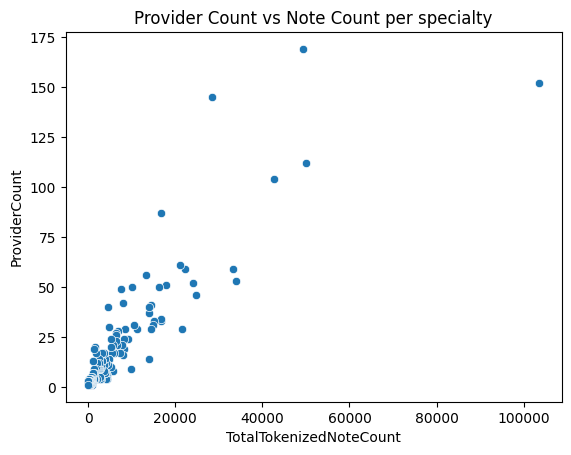

In [32]:
sns.scatterplot(data=df_grp_specialty, x='TotalTokenizedNoteCount',y='ProviderCount')
plt.title('Provider Count vs Note Count per specialty')
# high provider count mostly corresponds to higher notes count (there are variations!)

In [33]:
#analyzing notes by month
df_grp_monthlynotecount = df_notetokencost.groupby(['PrimarySpecialty', 'Year_Month_Service'], as_index=False)['ClinicalNoteEpicId'].count().reset_index(drop=True)
df_grp_monthlynotecount.rename(columns={'ClinicalNoteEpicId':'TotalNotes'}, inplace=True)
df_grp_monthlynotecount.head()

,PrimarySpecialty,Year_Month_Service,TotalNotes
0,Acupuncture,2024-12,370
1,Acupuncture,2025-01,563
2,Acupuncture,2025-02,517
3,Acupuncture,2025-03,500
4,Acupuncture,2025-04,652


In [34]:
df_grp_monthlynotecount[df_grp_monthlynotecount['PrimarySpecialty']=='Family Medicine']

,PrimarySpecialty,Year_Month_Service,TotalNotes
248,Family Medicine,2024-12,10894
249,Family Medicine,2025-01,14762
250,Family Medicine,2025-02,12924
251,Family Medicine,2025-03,14130
252,Family Medicine,2025-04,14481
253,Family Medicine,2025-05,13997
254,Family Medicine,2025-06,12904
255,Family Medicine,2025-07,6573
256,Family Medicine,2025-08,8
257,Family Medicine,2025-09,8


Text(0.5, 1.0, 'Monthly Total Notes (per specialty)')

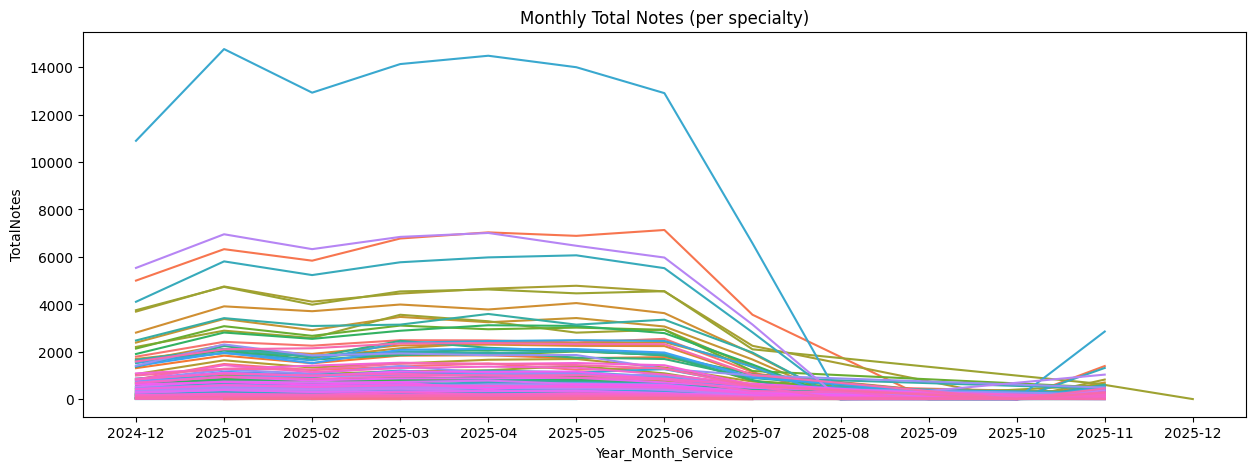

In [35]:
fig,ax = plt.subplots(figsize=(15,5))
sns.lineplot(data = df_grp_monthlynotecount.sort_values(by='Year_Month_Service'), x='Year_Month_Service', y='TotalNotes', hue='PrimarySpecialty', legend=False)
ax.set_title('Monthly Total Notes (per specialty)')

In [ ]:
# total cost per month and primaryspecialty
df_grp_monthlycost = df_notetokencost.groupby(['PrimarySpecialty','Year_Month_Service'], as_index=False)['TotalCostUSD'].sum().sort_values(by=['PrimarySpecialty','Year_Month_Service','TotalCostUSD'],ascending=False).reset_index(drop=True)

In [ ]:
df_grp_monthlycost[df_grp_monthlycost['PrimarySpecialty']=='Family Medicine']

,PrimarySpecialty,Year_Month_Service,TotalCostUSD
1041,Family Medicine,2025-11,15.340129
1042,Family Medicine,2025-10,0.053201
1043,Family Medicine,2025-09,0.046772
1044,Family Medicine,2025-08,0.094830
1045,Family Medicine,2025-07,37.194334
1046,Family Medicine,2025-06,72.148005
1047,Family Medicine,2025-05,76.061031
1048,Family Medicine,2025-04,78.110324
1049,Family Medicine,2025-03,74.660424
1050,Family Medicine,2025-02,68.806854


Text(0.5, 1.0, 'Monthly Token cost (USD) per specialty')

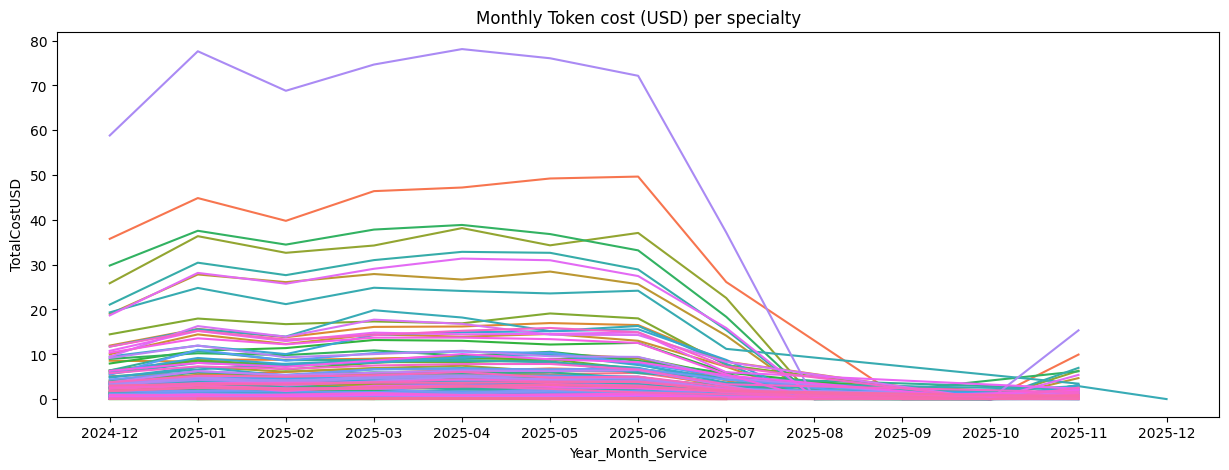

In [ ]:
fig,ax = plt.subplots(figsize=(15,5))
sns.lineplot(data = df_grp_monthlycost.sort_values(by='Year_Month_Service'), x='Year_Month_Service', y='TotalCostUSD', hue='PrimarySpecialty', legend=False)
ax.set_title('Monthly Token cost (USD) per specialty')